In [39]:
import pathlib
from typing import List, Optional
import os
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

In [40]:
EXP_NAME = "25_10_17_sllm_d2"
EXP_DIR = pathlib.Path("/u/marti.juanola/experiments", EXP_NAME)
OUT_DIR = pathlib.Path("/u/marti.juanola/Documents/tfm/images")

In [41]:
def load_scalars(logdir):
    ea = event_accumulator.EventAccumulator(
        logdir,
        size_guidance={
            event_accumulator.SCALARS: 0,
        },
    )
    ea.Reload()
    return ea


def _format_steps(x, pos):
    if x >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x / 1_000:.0f}k"
    return str(int(x))


def plot_scalar(ea, tag, outdir, log_name: Optional[str] = None, show: bool = True, figsize=(12, 8)):
    """Plot a single scalar tag from a single log."""
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(steps, values, linewidth=2)

    ax.set_xlabel("Step", fontsize=18)
    ax.set_ylabel(tag, fontsize=18)

    if log_name:
        title = f"{log_name} - {tag}"
    else:
        title = tag
    ax.set_title(title, fontsize=22, pad=12)

    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.set_major_formatter(FuncFormatter(_format_steps))

    ax.grid(True)
    fig.tight_layout()

    if show:
        plt.show()
    else:
        filename = title.replace("/", "_") + ".png"
        fig.savefig(os.path.join(outdir, filename), dpi=300)
        plt.close(fig)

def _ema_smooth(values: List[float], weight: float) -> List[float]:
    """Exponential moving average, matching TensorBoard's smoothing algorithm.

    Args:
        values: Raw scalar values.
        weight: Smoothing factor in [0, 1). 0 = no smoothing, ~0.99 = very heavy.
    """
    if weight == 0:
        return values
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

def plot_logs(
    run_dir: pathlib.Path,
    log_names: List[str],
    log_names_to_print: Optional[dict[str, str]] = None,
    scalars_to_plot: Optional[List[str]] = None,
    out_dir: pathlib.Path = OUT_DIR,
    show: bool = True,
    figsize: Optional[tuple[int, int]] = (12, 8),
    colors: Optional[List[str]] = None,
    title: Optional[str] = None,
    smooth: float = 0,
    y_max: Optional[dict[str, float]] = None,
):
    """Plot scalar tags from multiple logs on the same figure.

    One figure is created per scalar tag, with each log overlaid as a separate line.

    Args:
        log_names:       List of log directory names under RUN_DIR.
        scalars_to_plot: Tags to plot. Only tags available in at least one log are plotted;
                         tags missing from a particular log are silently skipped for that log.
        out_dir:         Directory to save figures when show=False.
        show:            If True, display interactively; otherwise save to out_dir.
        figsize:         Figure size in inches.
        colors:          Optional list of matplotlib color strings, one per log.
                         Falls back to the default color cycle if not provided.
        title:           Optional overall figure title. Defaults to the tag name.
        smooth:          EMA smoothing weight in [0, 1). 0 = off. When > 0, raw
                         values are shown faintly and the smoothed curve is drawn
                         on top in the same color.
    """
    if log_names_to_print is None:
        log_names_to_print = {}

    # Load all accumulators up front
    eas = {}
    for log_name in log_names:
        logdir = os.path.join(run_dir, log_name)
        eas[log_name] = load_scalars(logdir)

    # Collect the union of all available tags, then filter to requested ones
    all_tags = set()
    for ea in eas.values():
        all_tags.update(ea.Tags()["scalars"])

    tags_to_plot = [t for t in (scalars_to_plot or sorted(all_tags)) if t in all_tags]

    for tag in tags_to_plot:
        fig, ax = plt.subplots(figsize=figsize)

        for i, log_name in enumerate(log_names):
            ea = eas[log_name]
            if tag not in ea.Tags()["scalars"]:
                continue

            events = ea.Scalars(tag)
            steps = [e.step for e in events]
            values = [e.value for e in events]

            color = colors[i] if colors and i < len(colors) else None

            # Label
            label_name = log_name
            if log_name in log_names_to_print:
                label_name = log_names_to_print[log_name]

            if smooth > 0:
                ax.plot(steps, values, linewidth=1, alpha=0.2, color=color)
                ax.plot(steps, _ema_smooth(values, smooth), linewidth=2,
                        label=label_name, color=color)
            else:
                ax.plot(steps, values, linewidth=2, label=label_name, color=color)

        ax.set_xlabel("Steps", fontsize=18)
        ax.set_ylabel(tag, fontsize=18)

        fig_title = title if title else tag
        ax.set_title(fig_title, fontsize=22, pad=12)

        ax.tick_params(axis="both", labelsize=14)
        ax.xaxis.set_major_formatter(FuncFormatter(_format_steps))
        ax.legend(fontsize=13)
        ax.grid(True)
        if y_max and tag in y_max:
            ax.set_ylim(top=y_max[tag])
        fig.tight_layout()

        if show:
            plt.show()
        else:
            filename = (fig_title + " - " + tag).replace("/", "_") + ".png"
            fig.savefig(os.path.join(out_dir, filename), dpi=300)
            plt.close(fig)

## Pretrain only decoder

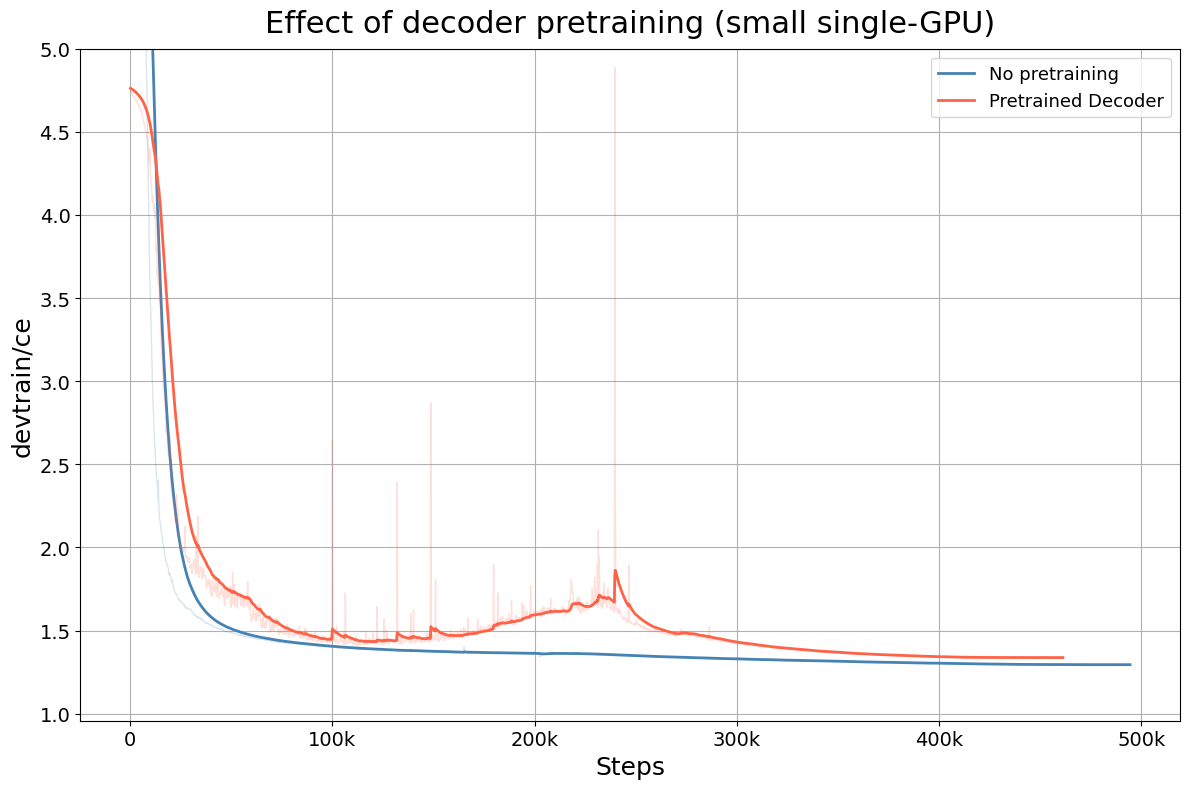

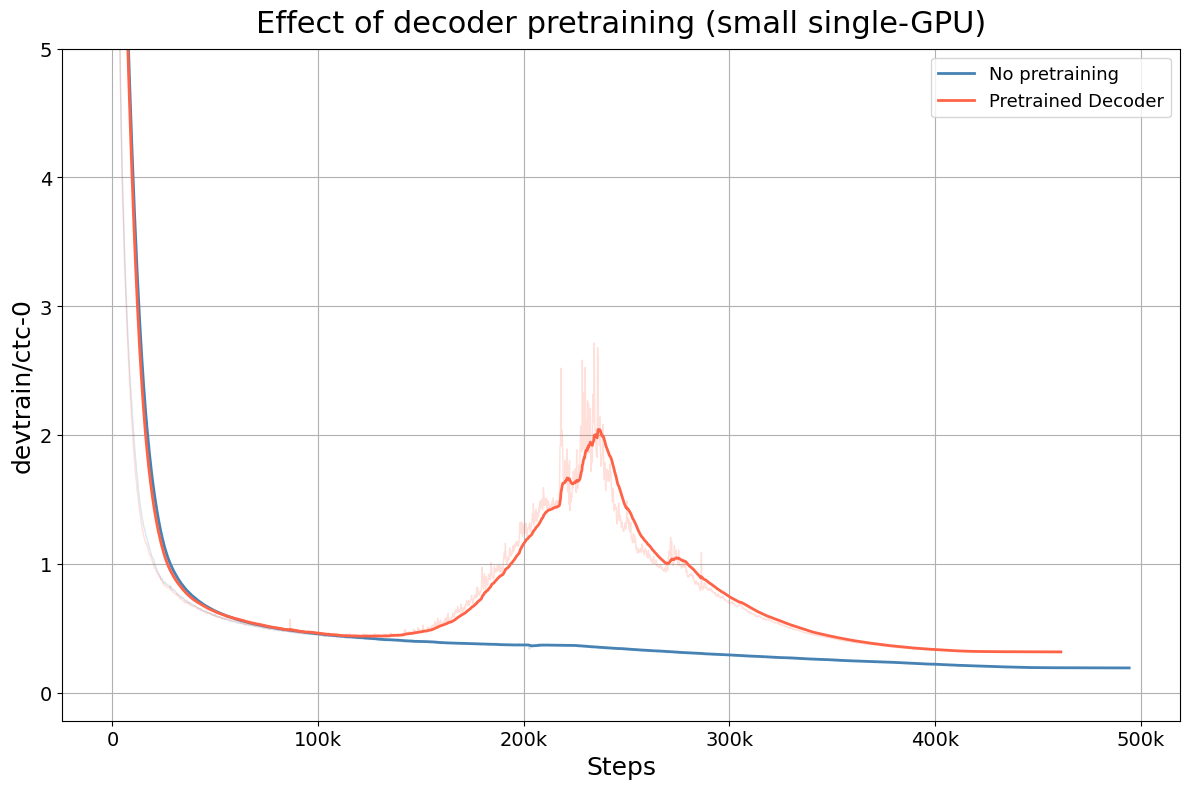

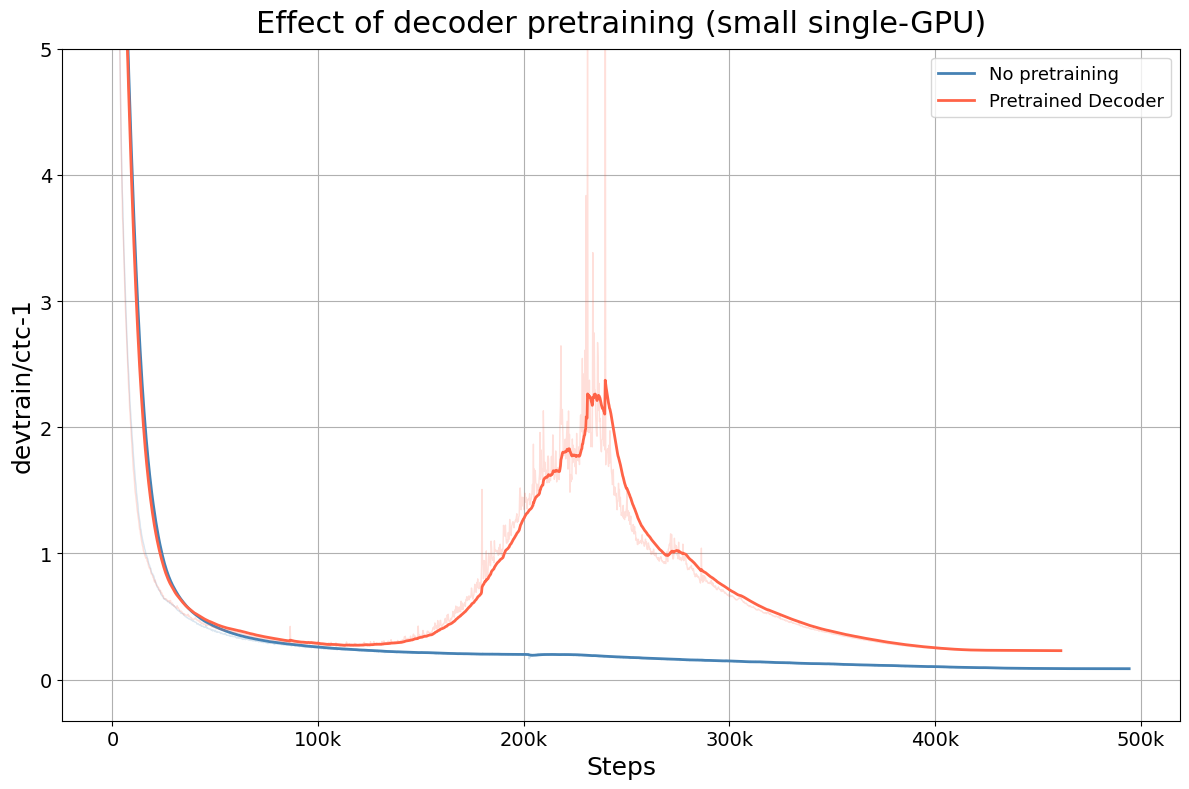

In [43]:
plot_logs(
    EXP_DIR.joinpath("runs","pre_dec"),
    log_names=["small_80k", "small_80k_pre_d"],
    log_names_to_print={
        "small_80k": "No pretraining",
        "small_80k_pre_d": "Pretrained Decoder",
    },
    scalars_to_plot=["devtrain/ce", "devtrain/ctc-0", "devtrain/ctc-1"],
    show=True,
    figsize=(12, 8),
    colors=["steelblue", "tomato", "seagreen"],
    title="Effect of decoder pretraining (small single-GPU)",
    smooth=0.95,
    y_max={
        "devtrain/ce": 5.0,
        "devtrain/ctc-0": 5.0,
        "devtrain/ctc-1": 5.0,
    },
)